In [1]:
# -*- coding: utf-8 -*-
"""
@author: Etienne Kras
"""

# generic imports
import sys
import os
import numpy as np
from pathlib import Path
import platform
import geopandas as gpd
import shapely
import pandas as pd
import time
import geemap
import json
import geojson
import ee
import math
from shapely import wkt

project = "bathymetry"
ee.Initialize(project=project) # use the GEE project-id here

# specific imports
from typing import Any, Dict, List, Optional
from geojson import Feature, FeatureCollection, dump
from shapely.geometry import Polygon, MultiPolygon, shape
from dateutil.relativedelta import *
from google.cloud import storage
from logging import Logger, getLogger
from googleapiclient.discovery import build
from re import sub
from ctypes import ArgumentError
from functools import partial
from dateutil.parser import parse

# custom functionality import without requirement to pip install package
local_path = r"C:\Users\kras\Documents\GitHub\ee-packages-py"  # path to local GitHub clone
sys.path.append(local_path)
from eepackages.applications.bathymetry import Bathymetry
from eepackages import tiler

logger: Logger = getLogger(__name__)

C:\Users\kras\AppData\Local\Temp\ipykernel_16132\1245777761.py:12: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [3]:
sdb_folder = r"11209821-cmems-global-sdb"

# project toggles
if platform.system().startswith("Windows"):
    main_fol = Path(r"p:\\") / sdb_folder
else:
    main_fol = Path("/mnt/p") / sdb_folder  # name of the main local folder 
bucket = "cmems-sdb" # name of the Google Cloud Storage bucket to store files in the cloud
credential_file = main_fol / "00_miscellaneous" / "KEYS" / "bathymetry-543b622ddce7.json" # Cloud Storage credential key
output_fol = r"01_intertidal/02_data/04_calibrated" # name of the overall project
aoi_fol = r"00_miscellaneous/AOI_upscale" #AOIs
mask_fol = r"00_miscellaneous/Feasibility_maps" # masks
project_name = "AOI_WestEurope" # name of the project AoI
draw_AoI = 0 # toggle 1 to draw AoI, 0 to load

# composite image toggles
mode = "intertidal_improved_100m_upscaled" # specify mode, either "intertidal" or "subtidal"
start_date = "2021-01-01" # start date of the composites
stop_date = "2022-01-01" # end date of the composites
compo_int = 12 # composite interval [months]
compo_len = 12 # composite length [months]
scale = 100  # output resolution of the image [m]
GEBCO_scale = 465 #m, actually 463 m but rounded up to the nearest 5 m 
crs = "EPSG:4326" # output projection of the image

# tiling options
zoomed_list = [9, 10, 11] # list with zoom levels to be inspected
sel_tile = 1 # idx of chosen tile level in zoomed_list (inspect the map to chose it accordingly)
# note, see https://www.openearth.nl/rws-bathymetry/2019.html; Z9 is optimal size..

# load google credentials, if specified
if not credential_file == "":  
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(credential_file)

# load GTSM & gebco data
gtsm_col = ee.FeatureCollection('projects/bathymetry/assets/gtsm_waterlevels')
gebco_image = ee.Image('projects/bathymetry/assets/gebco_2023_hat_lat')

### Retrieving the global intertidal processing area

In [4]:
# draw or load Area of Interest (AoI)

# TODO: take center of AOI input file if present, put in random coordinate and let user find a place and draw a polygon
# TODO: fix horizontal tiling error (DOS) in API (to use multiple tiles) or move to single polygon run if AoI crosses multiple tiles
Map = geemap.Map(center=(54.2, 6.7), zoom=8) # initialize map with base in Hudayriat

if draw_AoI == 1:
    print("Please draw a polygon somewhere in a water body") # identifier
if draw_AoI == 0:
    # open AoI
    print("Loading and visualizing AoI") #identifier
    #AoIee = geemap.geojson_to_ee(os.path.join(main_fol,'AOI',project_name+'.geojson'))

    with open(main_fol / aoi_fol / (project_name + ".geojson"), 'r') as f:
        contents = geojson.loads(f.read())
    AoIee = ee.Geometry.MultiPolygon(contents["features"][0]["geometry"]["coordinates"])

    Map.addLayer(AoIee, {}, "AoI")

Map # show map

Loading and visualizing AoI


Map(center=[54.2, 6.7], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

In [5]:
# (re)construct the AoI
if draw_AoI == 1:
    
    print("Constructing AoI from drawn polygon") # identifier
    
    # get AoI 
    AoIee = ee.FeatureCollection(Map.draw_features) # make featurecollection
    AoI = Polygon(AoIee.getInfo()["features"][0]["geometry"]["coordinates"][0]) # create AoI shapefile

    # export AoI
    features = []
    features.append(Feature(geometry=AoI, properties={"AoI": project_name}))
    AoIjson = FeatureCollection(features)
    with open(main_fol / "AOI" / (project_name + ".geojson"), "w") as f: # geojson
        dump(AoIjson, f)
    gdr = gpd.GeoDataFrame({"properties":{"AoI": project_name}, "geometry": AoI}, crs="EPSG:4326") #shp
    gdr.to_file(main_fol / "AOI" / (project_name+".shp"))
    bounds = ee.Geometry.Polygon([[[a,b] for a, b in zip(*AoI.exterior.coords.xy)]])
    
if draw_AoI == 0:
    print("Reconstructing AoI from loaded file")
    # get AoI
    with open(main_fol / aoi_fol / (project_name+".geojson")) as f:
        AoIjson = geojson.load(f)
    # try: # drawn polygon in this script
    #     AoI = Polygon(AoIjson["features"][0]["geometry"]["coordinates"]) 
    # except: # drawn in QGIS / ArcGIS and written to geojson there (client file)
    #     AoI = Polygon(AoIjson["features"][0]["geometry"]["coordinates"][0])
    # bounds = ee.Geometry.Polygon([[[a,b] for a, b in zip(*AoI.exterior.coords.xy)]])
    bounds = ee.Geometry.MultiPolygon(AoIjson["features"][0]["geometry"]["coordinates"])

    # make list of multipolygons a single one
    # MPL = []
    # for i in AoIjson["features"]:
    #     for j in i["geometry"]["coordinates"]:
    #         MPL.append(j)

    # bounds = ee.Geometry.MultiPolygon(MPL)

Reconstructing AoI from loaded file


### Coupling the global intertidal processing area (mask) to the AOI

In [6]:
# make the AoI a gdf dataframe (takes about 5 min), using geojson
gdf_AOI = gpd.GeoDataFrame.from_features(AoIjson)

# retrieve the (buffered) global coastal intertidal mask (geojson)
# allfiles = os.listdir(os.path.join(main_fol, mask_fol, "Buffered\AOI_results"))
# dfs = []
# for i in allfiles:
#     for j in os.listdir(os.path.join(main_fol, mask_fol, "Buffered\AOI_results", i)):
#         if "result.geojson" in j:
#             print(j) 
#             #open geojson
#             with open(os.path.join(main_fol, mask_fol, "Buffered\AOI_results", i, j)) as f:
#                 #data = geojson.load(f)
#                 df = gpd.read_file(f)

#                 # inner join to match the AOI and mask
#                 df_joined = df.sjoin(gdf_AOI, how="inner")

#                 dfs.append(df_joined) # append to list

# # concat the geodfs list
# gdfs = gpd.GeoDataFrame(pd.concat(dfs, ignore_index=True)) 

In [7]:
# retrieve the (buffered) global coastal intertidal mask (geojson), using parquet
allfiles = os.listdir(main_fol / mask_fol / "2024")#r"2023\Buffered\AOI_results")
for i in allfiles:
    if "gebco" in i and '.parquet' in i and "minus2" in i:
        print(i)
        # read parquet file
        df_buf = gpd.read_parquet(main_fol / mask_fol / "2024" / i)#r"2023\Buffered\AOI_results" / i) --> 1.1 million rows (polygons)

        # filter the data (3 = original, 2 = L-W mask, 1 = <HAT >LAT pixel)
        df_org = df_buf[df_buf["pixel_value"] == 3.0] # select only the pixels with value 3.0 (original) --> 415 k rows (polygons)

        # inner join to match the AOI and mask
        gdfs_org = df_org.sjoin(gdf_AOI, how="inner")

gebco_2024_latminus2_merge_result.parquet


In [8]:
# make a multipolygon
#df_mp_buf = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(df_buf.geometry))]}) #gdfs_buf
df_mp_org = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(gdfs_org.geometry))]}) #gdfs_org

# make a ee.Geometry.MultiPolygon to have bounds
# data_buf = json.loads(df_mp_buf.to_json())
# feature_collection_buf = geojson.FeatureCollection(data_buf['features'])
# bounds_buf = ee.Geometry.MultiPolygon(feature_collection_buf["features"][0]["geometry"]["coordinates"])

# make a ee.Geometry.MultiPolygon to have bounds
data_org = json.loads(df_mp_org.to_json())
feature_collection_org = geojson.FeatureCollection(data_org['features'])
bounds_org = ee.Geometry.MultiPolygon(feature_collection_org["features"][0]["geometry"]["coordinates"])

# add to map
#Map.addLayer(bounds_org, {}, "global intertidal feasibility mask")

### Tiling the AOI

In [9]:
# function for tiling the AoI and showing it on the map
def add_tile_bounds(zoom):
    tiled = tiler.get_tiles_for_geometry(bounds, zoom)
    Map.addLayer(tiled.style(width=max(1, 10 - zoom), fillColor= "00000022"), {}, "tiles " + str(zoom))

    return(tiled)

In [10]:
# for LAT-2

#Z9
# tiles9_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[0]))
# tiles9_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[0]))

#Z10
# tiles10_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[1]))
tiles10_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[1]))

# Z11 
# tiles11_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[2])) 
# tiles11_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[2])) 

In [11]:
print("buffered")
# print(tiles9_buf.size().getInfo())
# print(tiles10_buf.size().getInfo())
# print(tiles11_buf.size().getInfo())
print("original")
# print(tiles9_org.size().getInfo())
print(tiles10_org.size().getInfo())
# print(tiles11_org.size().getInfo())

buffered
original
175


### Coupling the global intertidal processing area (mask) to the global boxes

In [12]:
# load geojon for ICC ref regions
ref_regions = gpd.read_file(os.path.join(main_fol / "00_miscellaneous" / "IPCC_regions", "IPCC-WGI-reference-regions-v4.geojson"))
ref_regions.shape, ref_regions.head()

((58, 6),
   id      Continent  Type               Name Acronym  \
 0  0          POLAR  Land  Greenland/Iceland     GIC   
 1  1  NORTH-AMERICA  Land  N.W.North-America     NWN   
 2  2  NORTH-AMERICA  Land  N.E.North-America     NEN   
 3  3  NORTH-AMERICA  Land    W.North-America     WNA   
 4  4  NORTH-AMERICA  Land    C.North-America     CNA   
 
                                             geometry  
 0  POLYGON ((-10.00000 62.00000, -10.43750 62.000...  
 1  POLYGON ((-105.00000 50.00000, -105.43860 50.0...  
 2  POLYGON ((-50.00000 50.00000, -50.44000 50.000...  
 3  POLYGON ((-130.00000 50.00000, -129.56140 50.0...  
 4  POLYGON ((-90.00000 50.00000, -90.00000 49.561...  )

In [13]:
# retrieve the (buffered) global coastal intertidal mask (geojson), using parquet
allfiles = os.listdir(main_fol / mask_fol / "2024")#r"2023\Buffered\AOI_results")
for i in allfiles:
    if "gebco" in i and '.parquet' in i and "minus2" in i:
        print(i)
        # read parquet file
        df_buf = gpd.read_parquet(main_fol / mask_fol / "2024" / i)#r"2023\Buffered\AOI_results" / i) --> 1.1 million rows (polygons)

        # filter the data (3 = original, 2 = L-W mask, 1 = <HAT >LAT pixel)
        df_org = df_buf[df_buf["pixel_value"] == 3.0] # select only the pixels with value 3.0 (original) --> 415 k rows (polygons)

        # inner join to match the AOI and mask
        # gdfs_buf = df_buf.sjoin(gdf_AOI, how="inner")
        gdfs_org = df_org.sjoin(ref_regions, how="inner")

        # remove duplicates (with different AOIs we do not want to replicate the feasibility areas)
        gdfs_org_rd = gdfs_org[~gdfs_org.index.duplicated(keep='first')]

gebco_2024_latminus2_merge_result.parquet


In [16]:
# loop over the ref regions and export the boxes
for idx, i in enumerate(gdfs_org_rd["Acronym"].unique()):
    if i == "NEN" or i == "NWN" or i == "RAR" or i == "GIC" or i == "NEU" or i == "EAS": 
        print("%s of %s"%(idx, len(gdfs_org_rd["Acronym"].unique())), i) # print the progress
        gdfs_org_rd_fil = gdfs_org_rd[gdfs_org_rd["Acronym"] == i] # select the ref region

        # split dataframe if too large
        if gdfs_org_rd_fil.shape[0] > 15000:
            # Define a function to split the DataFrame
            def split_dataframe(df, chunk_size):
                num_chunks = int(np.ceil(len(df) / chunk_size))
                return [df[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]
            
            # Split the DataFrame into chunks of 10,000 rows
            chunk_size = 10000
            df_chunks = split_dataframe(gdfs_org_rd_fil, chunk_size)

        else: # if small enough (< 15000)
            df_chunks = [gdfs_org_rd_fil]

        for ids, dfs in enumerate(df_chunks):
            if len(df_chunks) > 1:
                print("chunk %s of %s" %(ids+1, len(df_chunks)))

            df_mp_org = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(dfs.geometry))]}) # make a multipolygon
            
            #make a ee.Geometry.MultiPolygon to have bounds
            data_org = json.loads(df_mp_org.to_json())
            feature_collection_org = geojson.FeatureCollection(data_org['features'])
            bounds_org = ee.Geometry.MultiPolygon(feature_collection_org["features"][0]["geometry"]["coordinates"])

            # compute the tiles
            tiles_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[sel_tile]))

            # export selected tiles (represented by zoom level) to geojsons
            # note, adjust sel_tile accordingly 
            if not os.path.exists(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i): # make folder to export
                os.mkdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)

            try: 
                for idx, tile in enumerate(tiles_org.getInfo()["features"]):
                    tile_pol = Polygon(tile['geometry']['coordinates'][0]) # create tile polygon
                    tile_name = "z%s_x%s_y%s"%(tile["properties"]["zoom"], int(float(tile["properties"]["tx"])), int(float(tile["properties"]["ty"])))

                    features = []
                    features.append(Feature(geometry=tile_pol, properties={"name": tile_name, "id":tile['id'], "tx":float(tile["properties"]["tx"]), "ty":float(tile["properties"]["ty"]), "zoom":int(float(tile["properties"]["zoom"]))}))
                    feature_collection = FeatureCollection(features)
                    feature_collection.crs = {"type": "name","properties": {"name": "epsg:3857"}} # default EE projection
                    with open(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / (tile_name + ".geojson"), "w") as f: # geojson
                        dump(feature_collection, f) 
            except Exception as e:
                print(e)

26 of 53 NEN
chunk 1 of 6
chunk 2 of 6


: 

: 

In [ ]:
# how many boxes do we have?
boxes = []
for i in os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world"):
    print(i, len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)))
    boxes.append(len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)))

# total number of boxes to run
print("Total number of boxes")
sum(boxes)

ARO 1507
ARP 363
ARS 47
BOB 45
CAF 71
CAR 464
CAU 96
CNA 47
EAN 1552
EAO 21
EAS 1061
EAU 157
EEU 7
EIO 200
ENA 733
EPO 409
ESAF 174
GIC 4095
MDG 211
MED 1130
NAO 86
NAU 507
NCA 306
NEAF 108
NEN 5799
NES 169
NEU 2210
NPO 406
NSA 219
NWN 2968
NWS 177
NZ 232
RAR 4116
RFE 960
SAH 238
SAO 12
SAS 325
SAU 346
SCA 418
SEA 2599
SEAF 85
SES 181
SIO 62
SOO 225
SPO 630
SSA 572
SWS 258
WAF 207
WAN 1373
WCA 103
WCE 325
WNA 174
WSAF 136
Total number of boxes


38922

In [553]:
# building a df of boxes, with some additional characteristics (perc of the area covered by the mask, area acronym, etc.)
df_boxes = pd.DataFrame()
for i in os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world"):
    if not ".csv" in i: #i == "WCE":
        print(i)
        for idx, j in enumerate(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)):
            #if j == "z10_x508_y363.geojson":
                print('% s of %s' % (idx, len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i))), flush=True, end="\r")

                # open the box as gpd
                with open(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / j) as f:
                    df = gpd.read_file(f)
                    df["path"] = main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / j
                    df["ref_region"] = i

                    # Perform spatial join are areas intersecting with the mask (as pre-filter)
                    joined_gdf = df_org.sjoin(df.to_crs("EPSG:4326"), how='inner', predicate='intersects') 
                    
                    # Intersection of polygons to the bounding box of the tile
                    cropped_gdf = gpd.overlay(joined_gdf, df.to_crs("EPSG:4326"), how='intersection')

                    # morphological erosion-dilation on the cropped_gdf
                    cero = cropped_gdf.buffer(-GEBCO_scale/2/111120) # divided by 2 to have half eroded on 2 sides (makes 1 in total) & fix for unequal buffer in EPSG3857: https://www.reddit.com/r/QGIS/comments/oo1jgh/buffer_points_on_epsg_4326_wgs_84/
                    cdil = cero.buffer(GEBCO_scale/2/111120) # get it back to the original (note empty geoemtries won't)
                    cdil = cdil[~cdil.is_empty] # removing the empty geometries

                    # make example plot
                    # ax = joined_gdf.plot()
                    # df.to_crs("epsg:4326").plot(ax=ax, linewidth=0.5, edgecolor='black', facecolor='none')
                    # cropped_gdf.plot(ax=ax, facecolor='red')
                    # cero.plot(ax=ax, facecolor='green')
                    # cdil.plot(ax=ax, facecolor='orange')

                    # calculate the area
                    df["area_perc_org"] = round((sum(cropped_gdf.geometry.area)/df.to_crs("epsg:4326").area)*100,2) # percentage of the area covered by the mask
                    df["area_perc_red"] = round((sum(cdil.area)/df.to_crs("epsg:4326").area)*100,2) # percentage of the area covered by the mask
                    #print(df)

                    # merge in
                    df_boxes = pd.concat([df_boxes, df], ignore_index=True)  

# make dataframe unique (i.e remove duplicate boxes)
print(df_boxes.shape)
df_boxes_un = df_boxes.drop_duplicates(subset=["name"])
print(df_boxes_un.shape)

# save the df
df_boxes_un.to_csv(main_fol / "00_miscellaneous" / "AOI_polygons_world" / ("df_boxes_world_Z" + str(zoomed_list[sel_tile]) + ".csv"))  

ARO
ARP6 of 1507
ARS of 363
BOBof 47
CAFof 45
CARof 71
CAU of 464
CNAof 96
EANof 47
EAO1 of 1552
EASof 21
EAU0 of 1061
EEU of 157
EIOf 7
ENA of 200
EPO of 733
ESAFof 409
GIC of 174
MDG4 of 4095
MED of 211
NAO9 of 1130
NAUof 86
NCA of 507
NEAFof 306
NEN of 108
NES8 of 5799
NEU of 169
NPO9 of 2210
NSA of 406
NWN of 219
NWS7 of 2968
NZ6 of 177
RAR of 232
RFE5 of 4116
SAH of 960
SAO of 238
SASof 12
SAU of 325
SCA of 346
SEA of 418
SEAF of 2599
SESof 85
SIO of 181
SOOof 62
SPO of 225
SSA of 630
SWS of 572
WAF of 258
WAN of 207
WCA2 of 1373
WCE of 103
WNA of 325
WSAFof 174


In [375]:
# test a single case in the loop above
m = df["geometry"].explore()
joined_gdf["geometry"].explore(m = m, style_kwds={'fillColor': 'blue', 'color': 'blue', 'fillOpacity': 0.5})
cropped_gdf["geometry"].explore(m = m, style_kwds={'fillColor': 'red', 'color': 'red', 'fillOpacity': 0.5})
cero.explore(m = m, style_kwds={'fillColor': 'green', 'color': 'green', 'fillOpacity': 0.5})
cdil.explore(m = m, style_kwds={'fillColor': 'orange', 'color': 'orange', 'fillOpacity': 0.5})

In [91]:
df_boxes_un.head()

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red
0,z10_x561_y116,2195,561.0,116.0,10,"POLYGON ((1917652.165849 15458624.600767, 1956...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,2.32,1.18
1,z10_x667_y108,13635,667.0,108.0,10,"POLYGON ((6066042.564986 15771710.668627, 6105...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,1.29,0.14
2,z10_x566_y141,2760,566.0,141.0,10,"POLYGON ((2113330.958262 14480230.638707, 2152...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.71,0.07
3,z10_x545_y140,491,545.0,140.0,10,"POLYGON ((1291480.030131 14519366.397189, 1330...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,22.14,21.76
4,z10_x644_y109,11152,644.0,109.0,10,"POLYGON ((5165920.11989 15732574.910144, 52050...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.42,0.00


In [ ]:
# File paths, open file again to calculate distances
file_path_boxes_csv = os.path.join(main_fol, '00_miscellaneous', 'AOI_polygons_world', 'df_boxes_world_Z{}.csv'.format(zoomed_list[sel_tile]))
file_path_stations_geojson = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations.geojson'

# Load boxes
df_boxes = pd.read_csv(file_path_boxes_csv, index_col=0) # EPSG3857 standard
df_boxes['geometry'] = df_boxes['geometry'].apply(wkt.loads)
gdf_boxes = gpd.GeoDataFrame(df_boxes, geometry='geometry', crs="EPSG:3857")
gdf_boxes = gdf_boxes.to_crs("EPSG:4326")

# Load GTSM stations
gdf_stations = gpd.read_file(file_path_stations_geojson) # EPSG4326 standard

In [ ]:
# Create a kd-tree for the stations
from scipy.spatial import cKDTree
tree = cKDTree(gdf_stations['geometry'].to_crs("EPSG:3857").apply(lambda x: (x.x, x.y)).tolist())

# Find the nearest station and its wrongfull (!) distance 
def find_nearest_station(row):
    dist, idx = tree.query((row['geometry'].centroid.x, row['geometry'].centroid.y)) 
    return pd.Series([int(idx), dist/1000, gdf_stations['geometry'][idx]]) # dist in km

# Find the nearest station
gdf_boxes[['idx_nearest_station', 'distance_nearest_station', 'nearest_station_coord']] = gdf_boxes.to_crs("EPSG:3857").apply(find_nearest_station, axis=1)

In [ ]:
# correct the wrongfull distance
def haversine_corr(tile):
    """
    Calculate the great-circle distance between two points on the Earth's surface using the Haversine formula.
    """
    # access the data
    lat1, lon1 = gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.iloc[0].y, gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.iloc[0].x  # Berlin
    lat2, lon2 = gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].y, gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].x   # Paris

    R = 6371  # Earth's radius in km

    # Convert latitude and longitude from degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c * 1000 # Distance in m

for idx, tile in enumerate(gdf_boxes["name"]):
    print("%s of %s"%(idx, len(gdf_boxes["name"])), flush=True, end="\r")
    gdf_boxes.loc[gdf_boxes["name"] == tile, "distance_nearest_station_corr"] = float(haversine_corr(tile))

# replace boxes dist with corrected distance
gdf_boxes = gdf_boxes.drop(columns=['distance_nearest_station'])
gdf_boxes = gdf_boxes.rename(columns={"distance_nearest_station_corr": "distance_nearest_station"})

In [ ]:
# save the df
gdf_boxes.to_crs("EPSG:3857").to_csv(main_fol / "00_miscellaneous" / "AOI_polygons_world" / ("df_boxes_world_dist_Z" + str(zoomed_list[sel_tile]) + ".csv")) 

In [380]:
# TODO: sort the dataframe in the order as wished for the processing routine
# TODO: filter 80 deg north and 73 deg south?

## Tests to filtering of boxes on other attributes by Ruben White & Etienne Kras

### 0. Packages

In [14]:
# Packages
import pandas as pd
import geopandas as gpd
import os
from shapely import wkt
from shapely.geometry import box
import matplotlib.pyplot as plt
import contextily as ctx

### 1. Settings

In [36]:
# Settings
dir_path_main= r'p:/11209821-cmems-global-sdb'
zoomed_list = [9, 10, 11]
sel_tile = 1

# File paths
file_path_boxes_csv = os.path.join(dir_path_main, '00_miscellaneous', 'AOI_polygons_world', 'df_boxes_world_dist_Z{}.csv'.format(zoomed_list[sel_tile]))
file_path_mask_parquet = os.path.join(dir_path_main, '00_miscellaneous', 'Feasibility_maps', '2024', 'gebco_2024_latminus2_merge_result.parquet')
file_path_stations_geojson = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations.geojson'

# Load boxes
df_boxes = pd.read_csv(file_path_boxes_csv, index_col=0) # EPSG3857 standard
df_boxes['geometry'] = df_boxes['geometry'].apply(wkt.loads)
gdf_boxes = gpd.GeoDataFrame(df_boxes, geometry='geometry', crs="EPSG:3857")
gdf_boxes = gdf_boxes.to_crs("EPSG:4326")

# Load mask
gdf_mask = gpd.read_parquet(file_path_mask_parquet) # EPSG4326 standard
#gdf_mask = gdf_mask.to_crs("EPSG:3857")
gdf_mask = gdf_mask[gdf_mask["pixel_value"] == 3.0]

# Load GTSM stations
gdf_stations = gpd.read_file(file_path_stations_geojson) # EPSG4326 standard
#gdf_stations = gdf_stations.to_crs("EPSG:3857")

In [38]:
gdf_boxes

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red,idx_nearest_station,nearest_station_coord,distance_nearest_station
0,z10_x561_y116,2195,561.0,116.0,10,"POLYGON ((17.22656 79.87430, 17.57813 79.87430...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,2.32,1.18,7499,POINT (17.33421 79.92993),3062.257304
1,z10_x667_y108,13635,667.0,108.0,10,"POLYGON ((54.49219 80.35700, 54.84375 80.35700...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,1.29,0.14,7502,POINT (54.76023 80.27526),12472.397724
2,z10_x566_y141,2760,566.0,141.0,10,"POLYGON ((18.98438 78.20656, 19.33594 78.20656...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.71,0.07,7487,POINT (18.46672 77.95945),35249.049969
3,z10_x545_y140,491,545.0,140.0,10,"POLYGON ((11.60156 78.27820, 11.95313 78.27820...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,22.14,21.76,7438,POINT (11.91355 78.40147),10215.705106
4,z10_x644_y109,11152,644.0,109.0,10,"POLYGON ((46.40625 80.29793, 46.75781 80.29793...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.42,0.00,7509,POINT (46.96189 80.35473),7708.247466
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38916,z10_x579_y615,2829,579.0,615.0,10,"POLYGON ((23.55469 -34.30714, 23.90625 -34.307...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,WSAF,0.05,0.00,12384,POINT (23.87167 -34.01961),20461.548711
38917,z10_x580_y615,2910,580.0,615.0,10,"POLYGON ((23.90625 -34.30714, 24.25781 -34.307...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,WSAF,0.31,0.00,12383,POINT (24.31151 -34.10007),22205.448921
38918,z10_x581_y615,2991,581.0,615.0,10,"POLYGON ((24.25781 -34.30714, 24.60938 -34.307...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,WSAF,0.46,0.07,12383,POINT (24.31151 -34.10007),13161.295204
38919,z10_x582_y614,3071,582.0,614.0,10,"POLYGON ((24.60938 -34.01624, 24.96094 -34.016...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,WSAF,0.07,0.00,18354,POINT (25.0375 -33.9675),25671.047896


In [16]:
df_boxes.loc[df_boxes['name'] == 'z10_x508_y363']

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red
38351,z10_x508_y363,688,508.0,363.0,10,"POLYGON ((-156543.033719 5792092.255609, -1174...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,WCE,20.11,18.91


In [39]:
# Create a bounding box
#bbox = box(-20, 35, 40, 70) # Europe
#bbox = box(-140, 40, -50, 80) # Canada
#bbox = box(3.0, 50.5, 7.5, 53.7) # Netherlands
#bbox = box(4, 52.7, 5, 53.7) # Netherlands
#bbox = box(4, 52.5, 5, 52.9) # North Holland coast
bbox = box(5.3, 53.15, 5.9, 53.6) # Wadden Sea; Ameland Tidal Inlet
#bbox = box(-99.5, 69.0, -99.0, 69.5) # King William Island


### 2. Filter based on morpohlogical erosion-dilation mask

In [40]:
# make bbox a geodataframe
gdf_bbox = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326")#.to_crs("EPSG:3857")

# Clip mask
base = gdf_mask[gdf_mask.intersects(gdf_bbox.unary_union)].copy()
gdf_mask_ = gdf_mask[gdf_mask.intersects(gdf_bbox.unary_union)].copy()

# Morphological erosion-dilation of mask with a buffer (1 pixel)
#gdf_mask_['geometry'] = gdf_mask_['geometry'].buffer(-100)
gdf_mask_['geometry'] = gdf_mask_['geometry'].buffer(-GEBCO_scale/2/111120) # divided by 2 to have half eroded on 2 sides (makes 1 in total) & fix for unequal buffer in EPSG3857: https://www.reddit.com/r/QGIS/comments/oo1jgh/buffer_points_on_epsg_4326_wgs_84/
gdf_mask_['geometry'] = gdf_mask_['geometry'].buffer(GEBCO_scale/2/111120) # get it back
gdf_mask_ = gdf_mask_[~gdf_mask_.is_empty] # removing the empty geometries

# Plot mask
#fig, ax = plt.subplots(figsize=(10, 10))
#gdf_bbox.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)
m = gdf_bbox.explore(style_kwds={'fillColor': 'none', 'color': 'black'}) 
#base.plot(ax=ax, facecolor='blue', alpha=0.5)
base.explore(m=m, style_kwds={'fillColor': 'blue', 'color': 'blue', 'fillOpacity': 0.5})
#gdf_mask_.plot(ax=ax, facecolor='red', alpha=0.5)
gdf_mask_.explore(m=m, style_kwds={'fillColor': 'red', 'color': 'red', 'fillOpacity': 0.5})
#ctx.add_basemap(ax, crs=gdf_mask_.crs, attribution='', source=ctx.providers.OpenStreetMap.Mapnik)

### 3. Filter based on distance to stations

In [95]:
# Create a kd-tree for the stations
from scipy.spatial import cKDTree
tree = cKDTree(gdf_stations['geometry'].to_crs("EPSG:3857").apply(lambda x: (x.x, x.y)).tolist())

# Find the nearest station and its wrongfull (!) distance 
def find_nearest_station(row):
    dist, idx = tree.query((row['geometry'].centroid.x, row['geometry'].centroid.y)) 
    return pd.Series([int(idx), dist/1000, gdf_stations['geometry'][idx]]) # dist in km

# Find the nearest station
gdf_boxes[['idx_nearest_station', 'distance_nearest_station', 'nearest_station_coord']] = gdf_boxes.to_crs("EPSG:3857").apply(find_nearest_station, axis=1)

In [97]:
# correct the wrongfull distance
def haversine_corr(tile):
    """
    Calculate the great-circle distance between two points on the Earth's surface using the Haversine formula.
    """
    # access the data
    lat1, lon1 = gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.iloc[0].y, gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.iloc[0].x  # Berlin
    lat2, lon2 = gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].y, gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].x   # Paris

    R = 6371  # Earth's radius in km

    # Convert latitude and longitude from degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c * 1000 # Distance in m

for idx, tile in enumerate(gdf_boxes["name"]):
    print("%s of %s"%(idx, len(gdf_boxes["name"])), flush=True, end="\r")
    gdf_boxes.loc[gdf_boxes["name"] == tile, "distance_nearest_station_corr"] = float(haversine_corr(tile))

# replace boxes dist with corrected distance
gdf_boxes = gdf_boxes.drop(columns=['distance_nearest_station'])
gdf_boxes = gdf_boxes.rename(columns={"distance_nearest_station_corr": "distance_nearest_station"})

In [124]:
# save the df
#gdf_boxes.to_csv(main_fol / "00_miscellaneous" / "AOI_polygons_world" / ("df_boxes_world_dist_Z" + str(zoomed_list[sel_tile]) + ".csv"))  

In [99]:
# effort to check distances
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on the Earth's surface using the Haversine formula.
    """
    R = 6371  # Earth's radius in km

    # Convert latitude and longitude from degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c  # Distance in km

def euclidean_approx(lat1, lon1, lat2, lon2):
    """
    Approximate the distance between two points assuming a Cartesian grid.
    """
    # Conversion factors
    lat_to_km = 111.32
    lon_to_km = 111.32 * math.cos(math.radians((lat1 + lat2) / 2))

    # Differences in km
    delta_x = (lon2 - lon1) * lon_to_km
    delta_y = (lat2 - lat1) * lat_to_km

    return math.sqrt(delta_x**2 + delta_y**2)  # Distance in km

def to_epsg_3857(lat, lon):
    """
    Convert coordinates from EPSG:4326 (latitude, longitude) to EPSG:3857 (meters).
    """
    R = 6378137  # Earth's radius in meters
    x = R * math.radians(lon)
    y = R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y

def euclidean_epsg_3857(lat1, lon1, lat2, lon2):
    """
    Calculate Euclidean distance in EPSG:3857.
    """
    # Convert to EPSG:3857
    x1, y1 = to_epsg_3857(lat1, lon1)
    x2, y2 = to_epsg_3857(lat2, lon2)
    
    # Compute Euclidean distance in meters
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2) / 1000  # Convert to kilometers

# Example coordinates
tile = "z10_x527_y332"
lat1, lon1 = gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.y, gdf_boxes[gdf_boxes["name"] == tile].geometry.centroid.x  # Berlin
lat2, lon2 = gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].y, gdf_boxes[gdf_boxes["name"] == tile].nearest_station_coord.iloc[0].x   # Paris

# # Calculate distances
haversine_distance = haversine(lat1, lon1, lat2, lon2) # this one is the most accurate!
euclidean_distance = euclidean_approx(lat1, lon1, lat2, lon2) # this is a close approx
distance_3857 = euclidean_epsg_3857(lat1, lon1, lat2, lon2) # this is not good at all..

haversine_distance, euclidean_distance, distance_3857


(9.842931260823896, 9.854004710237273, 16.45415139810272)

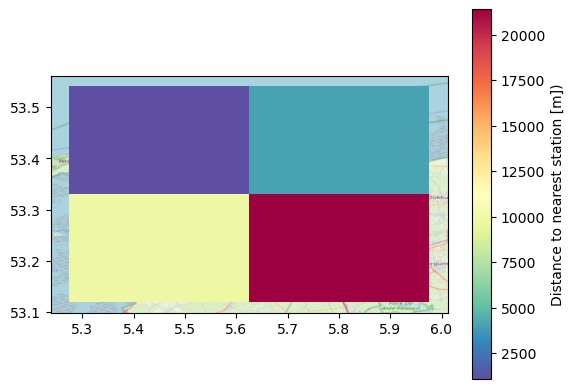

In [41]:
# Clip boxes
gdf_boxes_ = gdf_boxes[gdf_boxes.intersects(gdf_bbox.unary_union)].copy()

# Plot boxes
fig, ax = plt.subplots()
gdf_boxes_.plot(ax=ax, column='distance_nearest_station', cmap='Spectral_r', legend=True, legend_kwds={'label': "Distance to nearest station [m])"})
ctx.add_basemap(ax=ax, crs=gdf_boxes_.crs, attribution='', source=ctx.providers.OpenStreetMap.Mapnik)

In [43]:
gdf_boxes_

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red,idx_nearest_station,nearest_station_coord,distance_nearest_station
19827,z10_x528_y331,699,528.0,331.0,10,"POLYGON ((5.62500 53.33087, 5.97656 53.33087, ...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEU,40.07,39.16,19366,POINT (5.749512 53.415527),4064.036790
20394,z10_x527_y331,657,527.0,331.0,10,"POLYGON ((5.27344 53.33087, 5.62500 53.33087, ...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEU,39.49,37.99,3947,POINT (5.464587 53.43867),1074.042036
20663,z10_x528_y332,700,528.0,332.0,10,"POLYGON ((5.62500 53.12041, 5.97656 53.12041, ...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEU,0.99,0.94,19366,POINT (5.749512 53.415527),21387.409224
21205,z10_x527_y332,658,527.0,332.0,10,"POLYGON ((5.27344 53.12041, 5.62500 53.12041, ...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEU,57.48,57.27,21703,POINT (5.310059 53.195801),9842.931261


## POTENTIAL FILTERING GLOBAL RUN

In [ ]:
# NOTE: We filtered in GEE on 1 km, but this is the filter on tile_buffer. Tile_buffer is somewhat weird, difficult to filter on globally as you cannot compare with distance to nearest station and might include a lot of points
# better to move to calculate a dist from tile centroid to buffered (with x km) edge and then see if this is larger than the distance to the nearest station from the centroid. 
# Or we just set a threshold! (e.g. 1 km) and filter on that.

In [73]:
gdf_boxes.shape

(38659, 13)

In [77]:
# check how many 0s we have
gdf_boxes.sort_values(by='area_perc_red', ascending=False).tail(11488)

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red,idx_nearest_station,nearest_station_coord,distance_nearest_station
3187,z10_x517_y799,36617,517.0,799.0,10,"POLYGON ((1.75781 -70.61261, 2.10938 -70.61261...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,EAN,0.17,0.0,6973,POINT (3.033018 -70.60602),41054.426375
2949,z10_x762_y768,91221,762.0,768.0,10,"POLYGON ((87.89063 -66.65298, 88.24219 -66.652...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,EAN,0.59,0.0,7961,POINT (88.24331 -66.82398),27889.499032
3548,z10_x725_y791,82993,725.0,791.0,10,"POLYGON ((74.88281 -69.65709, 75.23438 -69.657...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,EAN,0.11,0.0,7955,POINT (75.78541 -69.59438),28177.760727
3223,z10_x444_y850,20389,444.0,850.0,10,"POLYGON ((-23.90625 -75.75894, -23.55469 -75.7...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,EAN,0.11,0.0,7881,POINT (-23.21615 -75.71748),14111.356053
17517,z10_x279_y150,17446,279.0,150.0,10,"POLYGON ((-81.91406 77.54210, -81.56250 77.542...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEN,0.89,0.0,7572,POINT (-78.73614 77.31433),78321.712152
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7201,z10_x381_y61,8757,381.0,61.0,10,"POLYGON ((-46.05469 82.76537, -45.70312 82.765...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,GIC,0.90,0.0,7769,POINT (-46.21023 82.66965),13903.123582
14688,z10_x263_y187,667,263.0,187.0,10,"POLYGON ((-87.53906 74.40216, -87.18750 74.402...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NEN,0.31,0.0,7590,POINT (-88.09197 74.48019),21971.644936
7198,z10_x465_y110,16450,465.0,110.0,10,"POLYGON ((-16.52344 80.23850, -16.17187 80.238...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,GIC,0.42,0.0,7668,POINT (-16.14353 80.31559),6511.632364
7192,z10_x385_y71,9131,385.0,71.0,10,"POLYGON ((-44.64844 82.30889, -44.29687 82.308...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,GIC,0.83,0.0,7768,POINT (-46.98151 82.38781),37594.623554


In [71]:
# remove the 0's from the df
gdf_boxes_red = gdf_boxes[gdf_boxes["area_perc_red"] > 0]

In [90]:
# check how many original perc we have below X%? 
# Here we test 1
gdf_boxes_red.sort_values(by='area_perc_org', ascending=False).tail(7141)

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc_org,area_perc_red,idx_nearest_station,nearest_station_coord,distance_nearest_station
8132,z10_x448_y274,4022,448.0,274.0,10,"POLYGON ((-22.50000 63.70472, -22.14844 63.704...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,GIC,0.99,0.12,21668,POINT (-22.426758 63.830566),7351.114299
7603,z10_x450_y263,4101,450.0,263.0,10,"POLYGON ((-21.79687 65.36684, -21.44531 65.366...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,GIC,0.99,0.25,18170,POINT (-21.26988 65.4706),16578.097603
11998,z10_x543_y398,3390,543.0,398.0,10,"POLYGON ((10.89844 36.87962, 11.25000 36.87962...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,MED,0.99,0.24,17781,POINT (10.99144 37.07116),9293.834070
25646,z10_x1035_y245,44203,1035.0,245.0,10,"POLYGON ((-176.13281 67.87554, -175.78125 67.8...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,RAR,0.99,0.44,8181,POINT (-176.1021 67.88789),8508.471761
32959,z10_x888_y528,9730,888.0,528.0,10,"POLYGON ((132.18750 -5.96575, 132.53906 -5.965...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,SEA,0.99,0.69,9401,POINT (132.3388 -5.571704),24520.203555
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35647,z10_x1023_y566,8076,1023.0,566.0,10,"POLYGON ((179.64844 -18.97903, -180.00000 -18....",p:\11209821-cmems-global-sdb\00_miscellaneous\...,SPO,0.03,0.03,19837,POINT (0 -17),202412.112220
21935,z10_x985_y455,20755,985.0,455.0,10,"POLYGON ((166.28906 19.31114, 166.64063 19.311...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NPO,0.03,0.02,23182,POINT (166.625977 19.291992),26612.985702
2093,z10_x321_y459,2112,321.0,459.0,10,"POLYGON ((-67.14844 17.97873, -66.79687 17.978...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,CAR,0.03,0.03,23349,POINT (-67.045898 17.973632),20647.846705
21913,z10_x950_y489,12879,950.0,489.0,10,"POLYGON ((153.98438 7.71099, 154.33594 7.71099...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,NPO,0.03,0.03,9846,POINT (151.8877 7.430284),255486.838562


In [93]:
# remove the 0's from the df
gdf_boxes_reds = gdf_boxes_red[gdf_boxes_red["area_perc_org"] >= 1]

In [94]:
gdf_boxes_reds.shape

(20030, 13)

In [114]:
# remove all at once, needs to be the same
#gdf_boxes_redss = gdf_boxes[(gdf_boxes["area_perc_red"] > 0) & (gdf_boxes["area_perc_org"] >= 1)]

# more restrictions, what is 50 km based on?
gdf_boxes_redss = gdf_boxes[(gdf_boxes["area_perc_red"] > 0) & (gdf_boxes["area_perc_org"] >= 1) & (gdf_boxes["distance_nearest_station"] <= 37000)]

In [115]:
print(gdf_boxes.shape)
print(gdf_boxes_redss.shape)

(38659, 13)
(16800, 13)


In [ ]:
# TODO: export the all boxes as parquet file and give them a legend which you can color to show in QGIS
# TODO: calculate statistics on IPCC regions, which regions has most boxes left in percentages?